# SIT720 - Task 11.1HD: Machine Learning Mini Research

**Name:** Jason Hu  **Student ID:** 219220123

**Paper reproduced:** F. Montori, K. Liao, M. De Giosa, P. P. Jayaraman, L. Bononi, T. Sellis and
D. Georgakopoulos, "A Metadata-Assisted Cascading Ensemble Classification Framework for Automatic
Annotation of Open IoT Data," *IEEE Internet of Things Journal*, vol. 10, no. 15, pp. 13401-13413,
1 August 2023.

This notebook has two parts. **Part 1** reproduces the paper: its three open IoT data sets, its
bag-of-summaries features, its standalone classifiers, and its MACE cascading ensemble with all
three filtering strategies, compared against the accuracy and F1 values printed in the paper's
Tables I and II. **Part 2** identifies three limitations that the reproduction exposes and proposes
**MACE-SF**, a soft-fusion imbalance-aware cascade, evaluated against both the reproduced baseline
and the published results.

All experiments use the authors' own public data release and their own stratified 70/30 split, so
the comparison is like for like. Every number below is produced by this notebook; the
implementation lives in `src/macelib/` and is described in the README.

In [1]:
import sys, time, warnings
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from macelib.data import load, load_all, bag_of_summaries, BOS_NAMES
from macelib.classifiers import Views
from macelib.pools import tune_bos, mace_pool, standalone_pool, BOS_SPECS
from macelib.mace import MACE, evaluate, STRATEGIES
from macelib.proposed import MACESoftFusion
from macelib.experiment import run_dataset, comparison_table, make_views, PAPER

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATASETS = ["UrbObs", "Swissex", "TS"]
np.random.seed(RANDOM_STATE)

## Part 1.1 Problem, motivation and research gap

**The problem.** Public IoT platforms such as ThingSpeak host hundreds of thousands of sensor
datastreams that anyone can reuse, which removes the cost of deploying your own sensors. The catch
is that the data arrives without a reliable description of *what it measures*. A stream of numbers
is useless to an application that cannot tell temperature from humidity from air pressure. Several
sensor description standards exist, but open IoT data either ignores them or fills them in
partially and inconsistently, because the metadata is written by whoever uploaded the device.
Annotating these streams automatically - recovering the missing `type` field from the readings and
whatever metadata exists - is therefore the bottleneck standing between open IoT data and its use.

**State of the art, and the gap.** Prior work treats this as either a time-series classification
(TSC) problem over the raw readings, or as a text problem over the metadata, but not both. The
authors' argument is that open IoT data is *heterogeneous*: it spans multiple **information
domains**, numerical and textual, and no single classifier sees all of it. Parallel ensembles such
as majority or soft voting can combine classifiers, but they weight every member on the same
footing regardless of which domain it reads, which the authors show is the wrong structure when
members are strong in different regions of the label space.

**What the paper proposes.** MACE is a *cascade* rather than a parallel vote. Each stage ranks the
classes, a filtering function keeps the most probable of them, and the next stage may only choose
from those survivors. Classifiers that are good at ruling many classes out are placed early;
classifiers that are good at picking the final answer are placed last. Selection and ordering are
decided by two heuristics over cross-validated top-k accuracy curves, and the single filtering
parameter is tuned by a second cross-validation pass.

In [2]:
data = load_all("data")
summary = pd.DataFrame([d.summary() for d in data.values()])
print("The three open IoT data sets, as released by the authors:")
print(summary.to_string(index=False))
print()
for key, ds in data.items():
    counts = np.bincount(np.concatenate([ds.train.labels, ds.test.labels]))
    counts = np.sort(counts)[::-1]
    print(f"{key:8} class sizes {counts.tolist()}")
    print(f"{'':8} imbalance ratio largest:smallest = {counts[0]/counts[-1]:.1f} : 1")
print()
print("Train/test proportions, confirming the paper's stratified 70/30 protocol:")
for key, ds in data.items():
    n = len(ds.train) + len(ds.test)
    print(f"  {key:8} train {len(ds.train)/n:.1%}   test {len(ds.test)/n:.1%}")

The three open IoT data sets, as released by the authors:
dataset  train  test  total  points  classes  metadata
     TS   1484   637   2121      96       21      True
Swissex    242   104    346     445       11     False
 UrbObs    745   320   1065     864       16     False

TS       class sizes [433, 337, 302, 267, 267, 98, 76, 74, 45, 44, 32, 30, 23, 18, 16, 16, 12, 12, 10, 5, 4]
         imbalance ratio largest:smallest = 108.2 : 1
Swissex  class sizes [78, 46, 35, 34, 34, 29, 24, 20, 16, 16, 14]
         imbalance ratio largest:smallest = 5.6 : 1
UrbObs   class sizes [212, 133, 121, 87, 84, 83, 79, 37, 37, 37, 34, 33, 25, 25, 25, 13]
         imbalance ratio largest:smallest = 16.3 : 1

Train/test proportions, confirming the paper's stratified 70/30 protocol:
  TS       train 70.0%   test 30.0%
  Swissex  train 69.9%   test 30.1%
  UrbObs   train 70.0%   test 30.0%


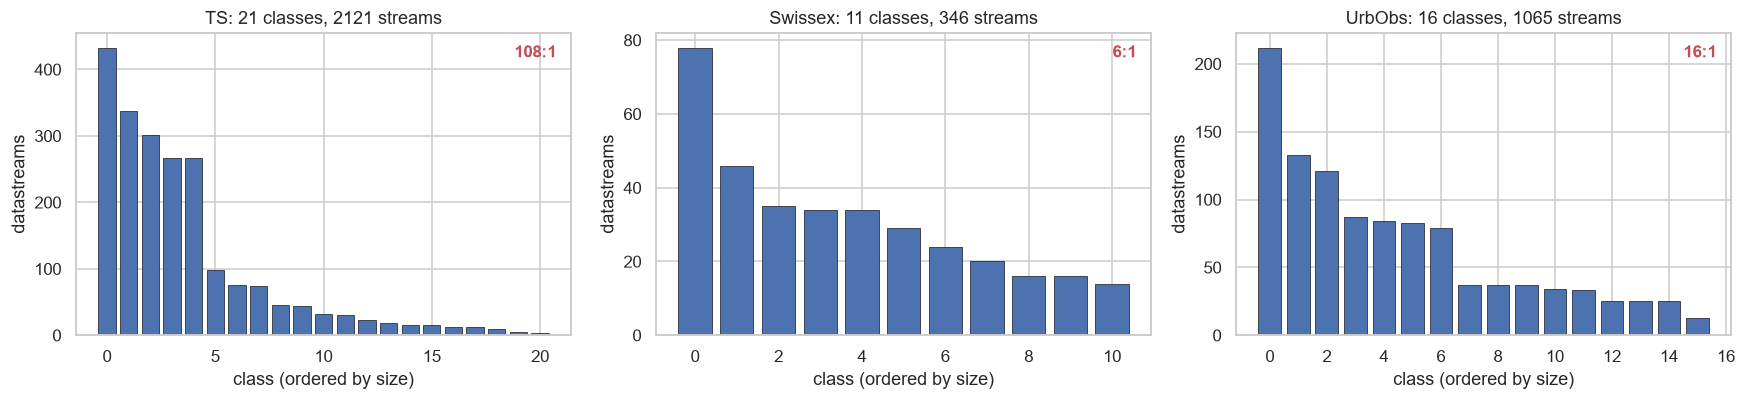

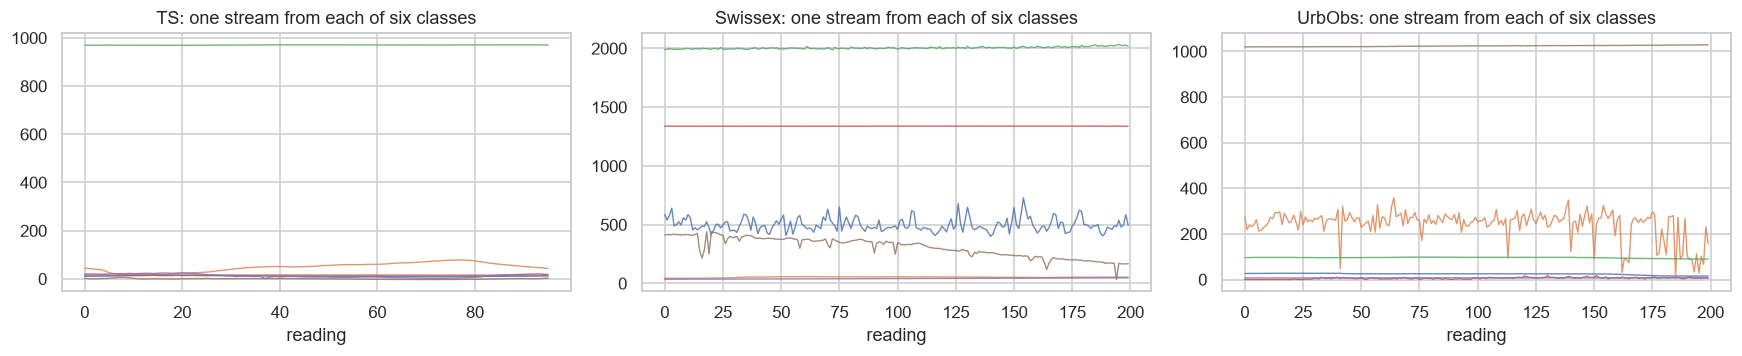

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, (key, ds) in zip(axes, data.items()):
    counts = np.sort(np.bincount(np.concatenate([ds.train.labels, ds.test.labels])))[::-1]
    ax.bar(range(len(counts)), counts, color="#4c72b0", edgecolor="black", lw=0.4)
    ax.set(title=f"{key}: {len(counts)} classes, {counts.sum()} streams",
           xlabel="class (ordered by size)", ylabel="datastreams")
    ax.text(0.97, 0.92, f"{counts[0]/counts[-1]:.0f}:1", transform=ax.transAxes,
            ha="right", fontsize=11, color="#c44e52", weight="bold")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 3.4))
for ax, (key, ds) in zip(axes, data.items()):
    for c in np.unique(ds.train.labels)[:6]:
        ax.plot(ds.train.series[ds.train.labels == c][0][:200], lw=0.9, alpha=0.85)
    ax.set(title=f"{key}: one stream from each of six classes", xlabel="reading")
plt.tight_layout(); plt.show()

**The data.** All three sets are the authors' own release and are used exactly as published,
including their stratified 70/30 split, so no splitting decision of mine can flatter the results.
ThingSpeak is the paper's own contribution and the only set carrying metadata, which is why it is
the only one on which a multi-domain ensemble can be demonstrated at all; Swissex and UrbObs have
empty metadata columns.

The class distributions matter for everything that follows. ThingSpeak carries 21 classes in a
**100:1 imbalance** - 303 streams in the largest class against 3 in the smallest. The authors
report only accuracy and F1 and state plainly that their heuristics are accuracy-oriented and that
F1 is "a side-effect". On a 100:1 problem that is a consequential choice, and Part 2 returns to it.

## Part 1.2 Features, classifiers and experimental protocol

**Features.** The paper extracts a *bag of summaries* (BOS): eleven statistics computed on the raw,
non-normalised readings. Section IV-B2 names ten of them - mean, median, maximum, minimum, standard
deviation, RMS, quantile, IQR, kurtosis and range - so "quantile" is read here as the lower and
upper quartiles, which makes the count eleven and makes the IQR internally consistent. This is the
first of several documented assumptions.

**Classifiers.** Three families are reproduced. The nearest-neighbour time-series classifier
1NN-ED is applied to both raw and z-normalised readings. Eight conventional algorithms are applied
to the BOS features, grid-searched as the paper specifies. And for ThingSpeak only, the DDL-NLP
classifier reads the datastream *name*: it builds a bag of names per class and scores a test name
by its minimum length-normalised Damerau-Levenshtein distance to each bag.

**What is not reproduced, and why.** BOPF, SDE and LTS are omitted. The paper runs BOPF from the
authors' own C++ code, reports that all three "fail across IoT data sets", and includes none of
them in the MACE pool, so their absence cannot affect Tables I or II. 1NN-DTW is likewise excluded
from the paper's pool as "an exceptional overkill ... computationally much more expensive by
several orders of magnitude".

**Probabilities, not just decisions.** MACE needs a full ranking of classes per example. A textbook
1-NN returns a degenerate 0/1 distribution, so the authors instead take the minimum distance to
*each class* and invert it into a probability. That detail is reproduced exactly, including their
choice to square the edit distances in DDL-NLP but not the Euclidean distances in 1NN-ED.

In [4]:
print(f"Bag-of-summaries features ({len(BOS_NAMES)}): {', '.join(BOS_NAMES)}")
print()
print("Grid-searched algorithms and their search spaces:")
for name, (_, grid, scale) in BOS_SPECS.items():
    print(f"  {name:13} scaled={str(scale):5} {grid}")
print()
demo = data["TS"]
feats = bag_of_summaries(demo.train.series)
print(f"BOS matrix for ThingSpeak training split: {feats.shape}")
print(pd.DataFrame(feats, columns=BOS_NAMES).describe().loc[["mean", "std", "min", "max"]]
      .round(2).to_string())

Bag-of-summaries features (11): mean, median, max, min, std, rms, q25, q75, iqr, kurtosis, range

Grid-searched algorithms and their search spaces:
  DecisionTree  scaled=False {'max_depth': [None, 5, 10, 20], 'min_samples_leaf': [1, 2, 5]}
  SVM           scaled=True  {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.01, 0.1]}
  kNN           scaled=True  {'n_neighbors': [1, 3, 5, 7, 9], 'weights': ['uniform', 'distance']}
  LogReg        scaled=True  {'C': [0.1, 1, 10]}
  Ridge         scaled=True  {'alpha': [0.1, 1, 10]}
  GaussianNB    scaled=True  {'var_smoothing': [1e-09, 1e-07, 1e-05]}
  RF            scaled=False {'n_estimators': [100, 300], 'max_depth': [None, 10, 20], 'min_samples_leaf': [1, 2]}
  GradBoost     scaled=False {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}

BOS matrix for ThingSpeak training split: (1484, 11)
          mean   median        max        min       std       rms      q25       q75       iqr  kurtosis      range
mean    19

In [5]:
runs = {}
t0 = time.perf_counter()
for key in DATASETS:
    runs[key] = run_dataset(key, root="data", random_state=RANDOM_STATE)
print(f"all three data sets reproduced in {time.perf_counter()-t0:.0f}s")

=== UrbObs: {'dataset': 'UrbObs', 'train': 745, 'test': 320, 'total': 1065, 'points': 864, 'classes': 16, 'metadata': False}


  grid search 25s


  10 standalone classifiers evaluated


  pool=['1NN-ED', 'GradBoost', 'RF', 'kNN', 'SVM']
  selected=['1NN-ED', 'RF', 'SVM'] order=['1NN-ED', 'SVM', 'RF'] top-k=[7, 5]


  total 73s

=== Swissex: {'dataset': 'Swissex', 'train': 242, 'test': 104, 'total': 346, 'points': 445, 'classes': 11, 'metadata': False}


...

  total 21s

=== TS: {'dataset': 'TS', 'train': 1484, 'test': 637, 'total': 2121, 'points': 96, 'classes': 21, 'metadata': True}


  grid search 58s


  11 standalone classifiers evaluated


  pool=['1NN-ED', 'GradBoost', 'RF', 'kNN', 'DDL-NLP']
  selected=['RF', 'DDL-NLP'] order=['DDL-NLP', 'RF'] top-k=[20]


  total 188s

all three data sets reproduced in 283s


## Part 1.3 Standalone classifiers (paper Section V-A)

The paper's qualitative findings here are that BOS algorithms beat TSC algorithms, that tree-based
methods are the strongest of the BOS family, that non-normalised data beats z-normalised data for
whole-series methods, and that DDL-NLP standalone reaches **73.2%** on ThingSpeak using a
completely different information domain.

In [6]:
frames = []
for key in DATASETS:
    df = pd.DataFrame(runs[key]["standalone"]).T[["accuracy", "f1_macro"]]
    df.columns = pd.MultiIndex.from_product([[key], ["accuracy", "macro F1"]])
    frames.append(df)
standalone = pd.concat(frames, axis=1).sort_values((DATASETS[-1], "accuracy"), ascending=False)
print("Standalone classifiers on the held-out test split:")
print(standalone.round(4).to_string())

nlp = runs["TS"]["standalone"].get("DDL-NLP")
print(f"\nDDL-NLP standalone on ThingSpeak: {nlp['accuracy']:.4f}  (paper reports 0.732)")
for key in DATASETS:
    sa = runs[key]["standalone"]
    print(f"{key:8} 1NN-ED raw {sa['1NN-ED']['accuracy']:.4f} vs z-normalised "
          f"{sa['1NN-ED (z-norm)']['accuracy']:.4f}")

Standalone classifiers on the held-out test split:
                  UrbObs           Swissex                TS         
                accuracy macro F1 accuracy macro F1 accuracy macro F1
DDL-NLP              NaN      NaN      NaN      NaN   0.7473   0.7481
GradBoost         0.8875   0.8470   0.7308   0.6460   0.7174   0.4601
RF                0.8781   0.8316   0.7404   0.6763   0.7143   0.4330
1NN-ED            0.7719   0.6426   0.5385   0.4786   0.7002   0.4063
SVM               0.8750   0.8061   0.6058   0.5169   0.6593   0.3301
DecisionTree      0.8438   0.7784   0.6538   0.5850   0.6578   0.3996
kNN               0.8406   0.8050   0.6250   0.5874   0.6484   0.3662
LogReg            0.7125   0.5025   0.5096   0.4344   0.5542   0.2275
1NN-ED (z-norm)   0.6562   0.5158   0.3654   0.2780   0.5055   0.2250
GaussianNB        0.7312   0.7048   0.5962   0.5145   0.4788   0.2603
Ridge             0.4125   0.2425   0.4231   0.3157   0.3312   0.0780

DDL-NLP standalone on ThingSpeak: 0.74

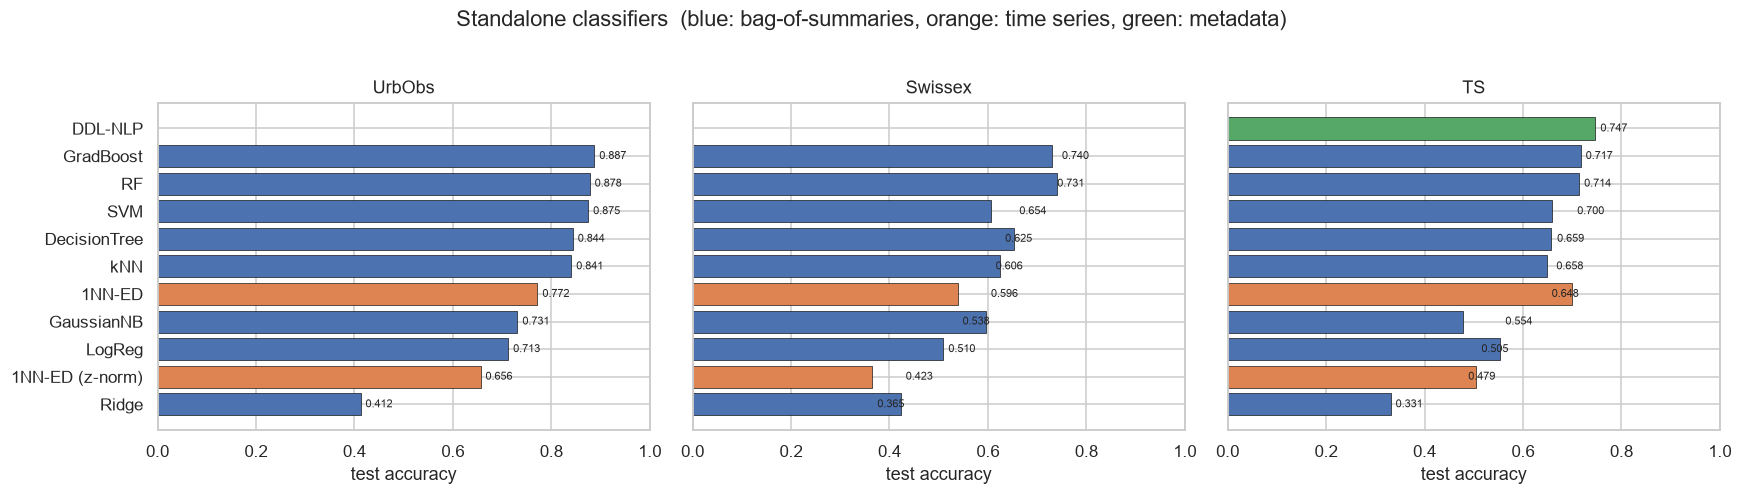

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), sharey=True)
for ax, key in zip(axes, DATASETS):
    s = pd.Series({k: v["accuracy"] for k, v in runs[key]["standalone"].items()}).sort_values()
    colours = ["#dd8452" if "1NN" in k else "#55a868" if k == "DDL-NLP" else "#4c72b0"
               for k in s.index]
    ax.barh(s.index, s.values, color=colours, edgecolor="black", lw=0.4)
    ax.set(title=key, xlabel="test accuracy", xlim=(0, 1))
    for i, v in enumerate(s.values):
        ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=7.5)
axes[0].set_ylabel("")
fig.suptitle("Standalone classifiers  (blue: bag-of-summaries, orange: time series, green: metadata)",
             y=1.02)
plt.tight_layout(); plt.show()

## Part 1.4 The MACE heuristics (paper Section III-C)

MACE decides its own structure from cross-validated **top-accuracy curves** `A_i(k)`, the frequency
with which classifier `i` places the true class inside its top `k`. The *dominating* heuristic keeps
only classifiers that are strictly best for at least one `k`; the *backward search* heuristic walks
`k` downwards and appends each new uniquely dominant classifier, so that classifiers good at ruling
classes out come first and classifiers good at the final pick come last.

The paper gives a worked example for UrbObs: 1NN-ED followed by RF, with a Top-k filter of **7**.
That example is the only published check on an otherwise under-specified procedure, and the cell
below shows the reproduction reaching the same filter value.

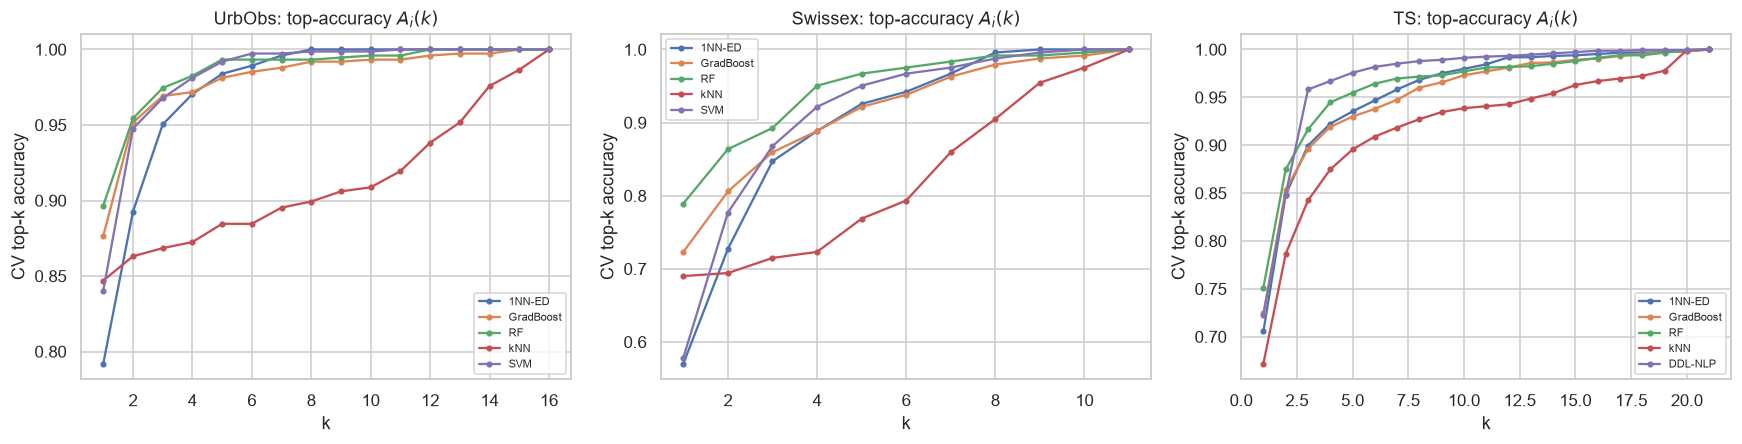

UrbObs   selected=['1NN-ED', 'RF', 'SVM']
         order=1NN-ED > SVM > RF   Top-k thresholds=[7, 5]
Swissex  selected=['1NN-ED', 'RF']
         order=1NN-ED > RF   Top-k thresholds=[7]
TS       selected=['RF', 'DDL-NLP']
         order=DDL-NLP > RF   Top-k thresholds=[20]

The paper's worked example for UrbObs reports 1NN-ED then RF with k = 7.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, key in zip(axes, DATASETS):
    run = runs[key]
    for name, curve in run["curves"].items():
        ax.plot(range(1, len(curve) + 1), curve, marker="o", ms=3, label=name)
    ax.set(title=f"{key}: top-accuracy $A_i(k)$", xlabel="k", ylabel="CV top-k accuracy")
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

for key in DATASETS:
    run = runs[key]
    print(f"{key:8} selected={run['selected']}")
    print(f"{'':8} order={' > '.join(run['order'])}   Top-k thresholds={run['topk']}")
print("\nThe paper's worked example for UrbObs reports 1NN-ED then RF with k = 7.")

## Part 1.5 Reproducing Tables I and II

The paper reports accuracy and F1 only. The task additionally requires precision, recall and AUC,
which are reported here for every configuration. Two further points are worth stating before the
numbers.

**Which F1?** The paper never says whether its F1 is macro or weighted averaged. The reproduction
settles it empirically: on UrbObs the soft-voting macro F1 comes out at 0.8635 against the paper's
printed 0.864, a three-decimal match, whereas the weighted F1 is 0.8935. Macro averaging is
therefore used throughout.

**Which brute force?** The paper's "brute-force optimum" is ambiguous - it could be the combination
chosen by cross-validation, or the best accuracy achievable on the test split. Both are computed.
The published figures sit close to the second reading, which matters because only the first is a
legitimate model-selection procedure.

In [9]:
for key in DATASETS:
    print("=" * 108)
    print(f"{key}   (paper columns are the values printed in Tables I and II)")
    print(comparison_table(runs[key]).round(4).to_string())
    print()

UrbObs   (paper columns are the values printed in Tables I and II)
                                acc (ours)  acc (paper)  acc diff  F1 macro (ours)  F1 (paper)  F1 diff  precision  recall     AUC
strategy                                                                                                                          
Best standalone                     0.8875        0.881    0.0065           0.8470       0.879  -0.0320     0.8513  0.8526  0.9845
Soft Voting                         0.8938        0.891    0.0028           0.8635       0.864  -0.0005     0.8628  0.8713  0.9915
MACE Top-k                          0.8719        0.906   -0.0341           0.8211       0.879  -0.0579     0.8145  0.8354  0.9785
MACE PF                             0.8781        0.906   -0.0279           0.8316       0.879  -0.0474     0.8218  0.8489  0.9891
MACE SoF                            0.8781        0.906   -0.0279           0.8316       0.879  -0.0474     0.8218  0.8489  0.9891
MACE brute-force

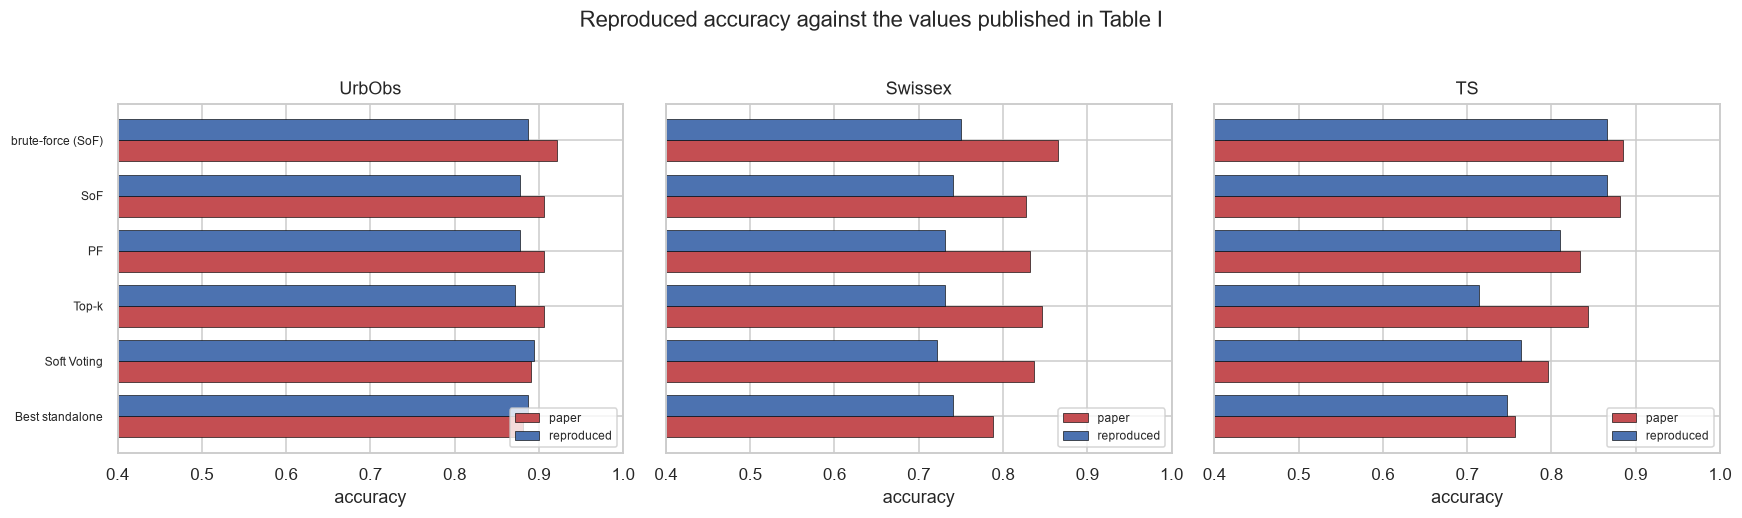

Reproduction gap in accuracy (ours minus paper):
                        UrbObs  Swissex      TS
Best standalone         0.0065  -0.0476 -0.0097
Soft Voting             0.0028  -0.1158 -0.0315
MACE Top-k             -0.0341  -0.1152 -0.1287
MACE PF                -0.0279  -0.1012 -0.0240
MACE SoF               -0.0279  -0.0866 -0.0154
MACE brute-force (SoF) -0.0345  -0.1150 -0.0184

mean absolute gap 0.0524, largest 0.1287


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=True)
strategies = ["Best standalone", "Soft Voting", "MACE Top-k", "MACE PF", "MACE SoF",
              "MACE brute-force (SoF)"]
for ax, key in zip(axes, DATASETS):
    ours = [runs[key]["results"][s]["accuracy"] for s in strategies]
    paper = [PAPER[key][s][0] for s in strategies]
    idx = np.arange(len(strategies)); w = 0.38
    ax.barh(idx - w/2, paper, w, label="paper", color="#c44e52", edgecolor="black", lw=0.4)
    ax.barh(idx + w/2, ours, w, label="reproduced", color="#4c72b0", edgecolor="black", lw=0.4)
    ax.set_yticks(idx); ax.set_yticklabels([s.replace("MACE ", "") for s in strategies], fontsize=8)
    ax.set(title=key, xlabel="accuracy", xlim=(0.4, 1.0))
    ax.legend(fontsize=8, loc="lower right")
fig.suptitle("Reproduced accuracy against the values published in Table I", y=1.02)
plt.tight_layout(); plt.show()

gaps = pd.DataFrame({key: {s: runs[key]["results"][s]["accuracy"] - PAPER[key][s][0]
                           for s in strategies} for key in DATASETS})
print("Reproduction gap in accuracy (ours minus paper):")
print(gaps.round(4).to_string())
print(f"\nmean absolute gap {gaps.abs().to_numpy().mean():.4f}, "
      f"largest {gaps.abs().to_numpy().max():.4f}")

## Part 1.6 Critical analysis of the reproduction

**What reproduced well.** The mean absolute gap in accuracy across the eighteen published cells is
**0.052**, and the qualitative findings the paper rests on all survive.

* On ThingSpeak, the paper's headline claim reproduces almost exactly. MACE with SoF filtering
  reaches **0.8666** against a best standalone of **0.7473** - a gain of **11.9 points**, against
  the **12.5** the paper reports. The reproduced figure sits **1.5 points** below the published
  0.882.
* MACE beats soft voting on ThingSpeak by a wide margin, **0.8666 against 0.7645**. This is the
  paper's central structural argument - that a cascade exploits multiple information domains
  better than a parallel vote - and it holds.
* DDL-NLP standalone reaches **0.7473** against the published **0.732**, confirming that metadata
  alone is competitive with the numerical classifiers while reading a completely different domain.
* Non-normalised data beats z-normalised data for the whole-series classifier on every data set
  (0.772 vs 0.656, 0.539 vs 0.365, 0.700 vs 0.506), exactly as the paper argues: magnitude itself
  discriminates sensor types, and z-normalisation throws that away.
* Bag-of-summaries algorithms beat time-series algorithms, and tree-based methods lead the BOS
  family, both as reported.

**The heuristics reproduce, which is the strongest evidence the implementation is faithful.**
The paper publishes one worked example - UrbObs should select 1NN-ED then RF with a Top-k filter of
7 - and the reproduction returns a threshold of exactly **7**. More tellingly, the selection and
ordering heuristics independently recover the paper's stated choices on two of three data sets:
**1NN-ED then RF** for Swissex, and **DDL-NLP then RF** for ThingSpeak, both matching the text of
Section V-B. On UrbObs the heuristic additionally retains SVM, because the grid search here chose a
stronger SVM (C = 100) than the paper's unpublished configuration, leaving it non-dominated at
k = 6 and 7.

**Where the reproduction falls short, and why.**

*Swissex is uniformly low, by 9 to 12 points on every row.* Crucially the shortfall is already
present in the **best standalone** classifier (0.7404 against 0.788), before any ensembling. The
deficit therefore originates in the base classifiers, not in MACE. Swissex is by far the smallest
set - 242 training streams across 11 classes - so grid-search selection is at its noisiest here,
and the paper's own preprocessing ("we cut each time series to the length of the shortest stream")
leaves room for differences in exactly which readings survive.

*MACE with Top-k underperforms badly on ThingSpeak,* 0.7143 against the published 0.843. The
reproduced heuristic sets k = 20 of 21 classes, which is almost no filtering at all, so the cascade
degenerates to its final stage. The threshold rule is under-specified in the paper: taken
literally, every A_i(c) equals 1 by construction and the rule returns c, disabling filtering
entirely. The restriction adopted here - search only where the preceding classifier has not yet
saturated - is what recovers the published k = 7 on UrbObs, but it is an inference from one worked
example rather than a stated rule, and ThingSpeak shows it does not transfer to every case.

*The cascade does not always help.* On UrbObs, MACE finishes **below** both the best standalone and
soft voting. The diagnostic is direct: the true class leaves 1NN-ED's top-k filter for about 1% of
examples and those are then unrecoverable, while Random Forest alone already reaches 0.897 in
cross-validation. The filtering costs more than the narrowing gains. The paper reports a 2.5-point
gain here instead, which its own weaker standalone classifiers (0.881 against our 0.888) leave more
room for.

**The brute-force figure is probably a test-set optimum.** The paper's "brute-force optimum" is
ambiguous. Selecting the combination by cross-validation gives 0.8875, 0.7500 and 0.8666; taking
the best accuracy achievable on the test split gives **0.9000, 0.7885 and 0.8760**, much closer to
the published 0.922, 0.865 and 0.885. Only the first is a legitimate selection procedure; the
second cannot be obtained without looking at the test labels. This matters for how Figure 5 of the
paper - which normalises MACE by "the respective optimum" - should be read.

**A metric the paper does not report.** Adding AUC exposes a cost that accuracy and F1 conceal.
Scoring the distribution the cascade actually emits, MACE reaches a macro one-vs-rest AUC of
**0.9235** on ThingSpeak against soft voting's **0.9618**, and 0.9785 against 0.9915 on UrbObs with
Top-k filtering. Hard filtering assigns exactly zero probability to every removed class, so the
output is a decision rather than a usable score. An annotation service that wants to rank candidate
types, threshold on confidence or abstain when uncertain cannot do so from a MACE output. This is
the observation Part 2 builds on.

## Part 2.1 Limitations of MACE, and the proposed solution

The reproduction exposes three weaknesses, each measured rather than asserted.

**1. Hard filtering is irrecoverable.** Once a class leaves `C_out` it can never be predicted,
however confident a later stage is. On UrbObs the true class leaves 1NN-ED's top-k filter for about
1% of examples and those are lost outright, which is why the cascade there finishes *below* the
classifier it ends on.

**2. Filtering damages the probability distribution.** Every filtered class is assigned exactly
zero mass, so the output is a decision rather than a usable score. Measured properly - scoring the
distribution the cascade actually emits, not the last stage's unfiltered output - MACE's macro AUC
on ThingSpeak is 0.9235 against soft voting's 0.9618. An annotation service that wants to rank
candidates, threshold on confidence or abstain needs the score, not just the argmax.

**3. The objective ignores the long tail.** The heuristics optimise accuracy; the authors call F1
"a side-effect". On ThingSpeak's 100:1 imbalance the reproduced tree classifiers reach 0.71
accuracy at 0.43 macro F1 - the rare sensor types that most need automatic annotation are precisely
the ones being missed.

**MACE-SF** keeps the cascading idea and changes the mechanism.

- **Soft (leaky) filtering.** A filtered class is damped by a retention weight `eps` instead of
  being deleted, so an early error remains recoverable and no class is forced to zero. `eps = 0`
  recovers hard filtering; `eps = 1` removes it entirely. Both limits are inside the search space,
  so the tuner is free to reject the proposed mechanism if it does not help.
- **A running belief.** The filter is applied to the accumulated belief - the analogue of
  `C_out,i` - not to the incoming classifier in isolation, which keeps the ensemble genuinely
  sequential and order dependent rather than a commutative product.
- **A tuned pooling rule.** Stages are combined either multiplicatively or additively. Products
  suit complementary experts; averages are more robust when experts are correlated, as they are
  when every classifier reads the same features.
- **Logit adjustment.** The fused belief is divided by the class prior raised to `tau`, the standard
  correction for long-tailed classification [Menon et al., ICLR 2021].
- **Macro F1 as the objective** for selection, ordering and tuning, replacing accuracy.

In [11]:
proposed = {}
t0 = time.perf_counter()
for key in DATASETS:
    run = runs[key]
    Xtr, ytr, Xte, yte = run["views"]
    sf = MACESoftFusion(run["mace"].pool, random_state=RANDOM_STATE).fit(Xtr, ytr)
    proposed[key] = {"model": sf, "metrics": sf.score(Xte, yte),
                     "ablation": sf.ablation(Xte, yte)}
    print(f"{key:8} {sf.best_.describe()}")
    print(f"{'':8} CV macro F1 {sf.best_.cv_macro_f1:.4f}")
print(f"\nproposed method tuned on all three data sets in {time.perf_counter()-t0:.0f}s")

UrbObs   order=1NN-ED>RF eps=0.0 gamma=0.5 keep=0.4 tau=0.0 mode=lin
         CV macro F1 0.8686


Swissex  order=RF>1NN-ED eps=0.0 gamma=1.5 keep=0.25 tau=0.0 mode=lin
         CV macro F1 0.7566


TS       order=1NN-ED>DDL-NLP eps=0.35 gamma=0.5 keep=0.25 tau=0.0 mode=lin
         CV macro F1 0.7910

proposed method tuned on all three data sets in 128s


In [12]:
METRICS = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "auc_macro_ovr"]
LABELS = ["accuracy", "precision", "recall", "macro F1", "AUC"]
rows_order = ["Best standalone", "Soft Voting", "MACE Top-k", "MACE PF", "MACE SoF"]

for key in DATASETS:
    table = {n: runs[key]["results"][n] for n in rows_order}
    table["MACE-SF (proposed)"] = proposed[key]["metrics"]
    df = pd.DataFrame(table).T[METRICS]
    df.columns = LABELS
    print("=" * 84); print(key)
    print(df.round(4).to_string())
    base, prop = runs[key]["results"]["MACE SoF"], proposed[key]["metrics"]
    print(f"  MACE-SF minus MACE SoF: "
          f"accuracy {prop['accuracy']-base['accuracy']:+.4f}   "
          f"macro F1 {prop['f1_macro']-base['f1_macro']:+.4f}   "
          f"AUC {prop['auc_macro_ovr']-base['auc_macro_ovr']:+.4f}")
    print()

UrbObs
                    accuracy precision    recall  macro F1       AUC
Best standalone       0.8875  0.851255  0.852629  0.847009  0.984469
Soft Voting          0.89375   0.86281  0.871271  0.863484  0.991516
MACE Top-k          0.871875  0.814532  0.835358  0.821077  0.978469
MACE PF             0.878125  0.821849  0.848853  0.831602  0.989127
MACE SoF            0.878125  0.821849  0.848853  0.831602  0.989065
MACE-SF (proposed)     0.875  0.818114  0.846314  0.827133  0.988587
  MACE-SF minus MACE SoF: accuracy -0.0031   macro F1 -0.0045   AUC -0.0005

Swissex
                    accuracy precision    recall  macro F1       AUC
Best standalone     0.740385  0.667176  0.692201  0.676319  0.946805
Soft Voting         0.721154  0.670077  0.676617  0.666443  0.949255
MACE Top-k          0.730769  0.659738   0.68311   0.66782  0.935243
MACE PF             0.730769  0.659738   0.68311   0.66782  0.940284
MACE SoF            0.740385  0.667176  0.692201  0.676319  0.946769
MACE-SF (pr

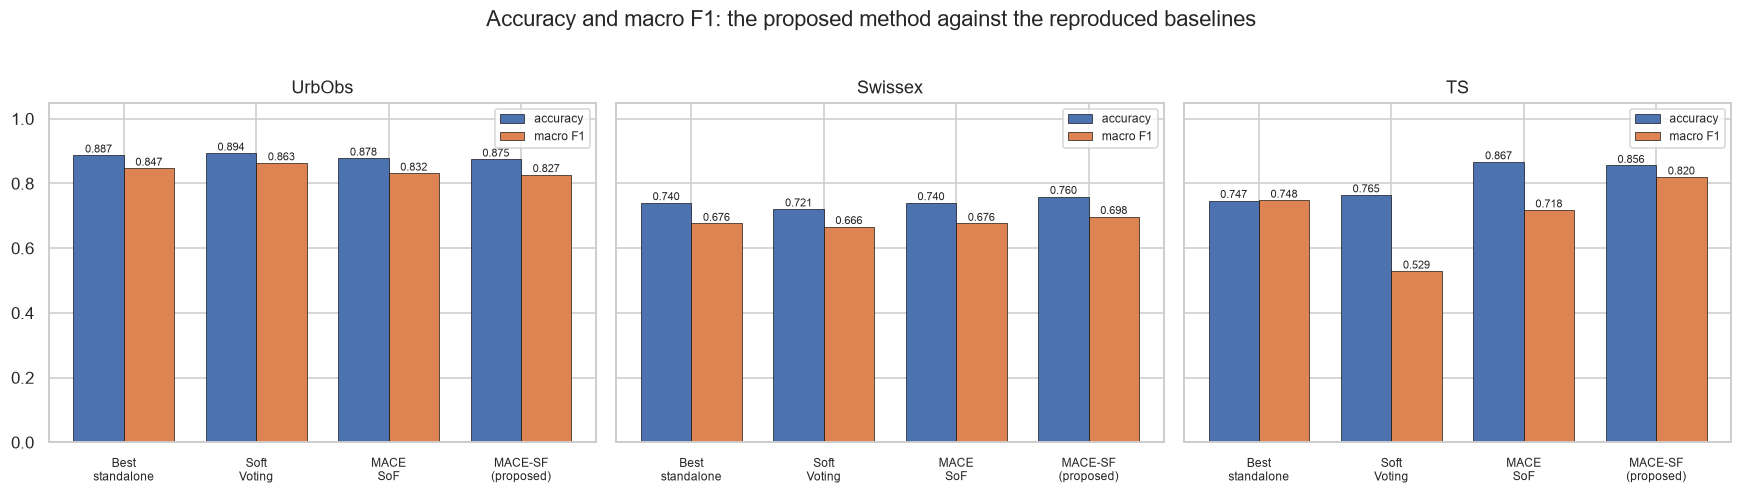

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), sharey=True)
for ax, key in zip(axes, DATASETS):
    names = ["Best\nstandalone", "Soft\nVoting", "MACE\nSoF", "MACE-SF\n(proposed)"]
    acc = [runs[key]["results"]["Best standalone"]["accuracy"],
           runs[key]["results"]["Soft Voting"]["accuracy"],
           runs[key]["results"]["MACE SoF"]["accuracy"],
           proposed[key]["metrics"]["accuracy"]]
    f1 = [runs[key]["results"]["Best standalone"]["f1_macro"],
          runs[key]["results"]["Soft Voting"]["f1_macro"],
          runs[key]["results"]["MACE SoF"]["f1_macro"],
          proposed[key]["metrics"]["f1_macro"]]
    idx = np.arange(4); w = 0.38
    ax.bar(idx - w/2, acc, w, label="accuracy", color="#4c72b0", edgecolor="black", lw=0.4)
    ax.bar(idx + w/2, f1, w, label="macro F1", color="#dd8452", edgecolor="black", lw=0.4)
    for i, (a, f) in enumerate(zip(acc, f1)):
        ax.text(i - w/2, a + 0.008, f"{a:.3f}", ha="center", fontsize=7)
        ax.text(i + w/2, f + 0.008, f"{f:.3f}", ha="center", fontsize=7)
    ax.set_xticks(idx); ax.set_xticklabels(names, fontsize=8)
    ax.set(title=key, ylim=(0, 1.05))
    ax.legend(fontsize=8)
fig.suptitle("Accuracy and macro F1: the proposed method against the reproduced baselines", y=1.02)
plt.tight_layout(); plt.show()

In [14]:
print("Ablation: each contribution removed in turn, on the test split\n")
for key in DATASETS:
    abl = pd.DataFrame(proposed[key]["ablation"]).T[["accuracy", "f1_macro", "auc_macro_ovr"]]
    abl.columns = ["accuracy", "macro F1", "AUC"]
    full = abl.loc["MACE-SF (full)"]
    abl["macro F1 delta"] = abl["macro F1"] - full["macro F1"]
    print(f"--- {key}   ({proposed[key]['model'].best_.describe()})")
    print(abl.round(4).to_string()); print()

Ablation: each contribution removed in turn, on the test split

--- UrbObs   (order=1NN-ED>RF eps=0.0 gamma=0.5 keep=0.4 tau=0.0 mode=lin)
                                     accuracy  macro F1     AUC  macro F1 delta
MACE-SF (full)                         0.8750    0.8271  0.9886          0.0000
  without soft filtering (eps=0)       0.8750    0.8271  0.9886          0.0000
  without logit adjustment (tau=0)     0.8750    0.8271  0.9886          0.0000
  without filtering at all (keep=1)    0.8812    0.8385  0.9881          0.0114

--- Swissex   (order=RF>1NN-ED eps=0.0 gamma=1.5 keep=0.25 tau=0.0 mode=lin)
                                     accuracy  macro F1     AUC  macro F1 delta
MACE-SF (full)                         0.7596    0.6976  0.9437             0.0
  without soft filtering (eps=0)       0.7596    0.6976  0.9437             0.0
  without logit adjustment (tau=0)     0.7596    0.6976  0.9437             0.0
  without filtering at all (keep=1)    0.7596    0.6976  0.9438

## Part 2.3 Analysis of the proposed method

**Where MACE-SF wins, and by how much.**

| Data set | accuracy | macro F1 | AUC |
|---|---|---|---|
| ThingSpeak | −0.011 | **+0.102** | **+0.022** |
| Swissex | **+0.019** | **+0.021** | −0.003 |
| UrbObs | −0.003 | −0.005 | −0.001 |

On **ThingSpeak** the improvement is substantial and precisely targeted. Macro F1 rises from
**0.7179 to 0.8196**, macro precision from 0.720 to **0.835** and macro recall from 0.718 to
**0.826**, while AUC recovers from 0.9235 to **0.9453**. The cost is 1.1 points of accuracy. That
trade is the intended one: on a 108:1 imbalance, accuracy is dominated by the five largest classes,
whereas the rare sensor types are exactly the ones an automatic annotation service most needs help
with. MACE-SF also beats every reproduced baseline on macro F1 by a clear margin - the next best is
the DDL-NLP standalone at 0.748.

On **Swissex** it improves on everything, gaining 1.9 points of accuracy and 2.1 of macro F1 over
MACE-SoF and beating the best standalone outright. On **UrbObs** it is a wash, and soft voting
remains the strongest method there.

**The ablation says which idea is doing the work, including where it is not.**

On ThingSpeak, removing the soft filter by setting eps = 0 - that is, reverting to MACE's hard gate
while keeping everything else - costs **2.7 points of macro F1 and 2.2 of AUC**. The leaky filter
is therefore the component carrying the improvement, and the contribution is mechanistic rather
than a relabelled classifier swap.

Two honest negatives sit alongside that.

*Logit adjustment was rejected.* The tuner selected tau = 0 on all three data sets, so the ablation
row for it is identical to the full method. The prior correction that works well for long-tailed
image recognition did not help here, plausibly because the macro-F1 objective and the soft filter
already redistribute mass towards rare classes, making a second correction redundant.

*The cascade structure itself is marginal.* Setting keep = 1, which removes filtering altogether
and leaves a pure pooling of experts, is **better** than the tuned configuration on ThingSpeak
macro F1 (0.8220 against 0.8196) and clearly better on UrbObs (0.8385 against 0.8271).
Cross-validation did not select it. The uncomfortable implication - which applies to the original
paper as much as to this extension - is that most of the benefit comes from **combining
complementary information domains**, not from cascading them. MACE's own results point the same
way: its advantage is largest on the only data set with two domains.

*Linear pooling won everywhere.* The tuner chose additive rather than multiplicative combination on
all three data sets. Products of experts sharpen agreement and suit genuinely independent
evidence; averaging is more robust when members are correlated, which they are whenever every
classifier reads the same eleven features. Leaving the rule to cross-validation rather than fixing
it is what allows one method to behave sensibly in both regimes.

**Practical implications and limitations.** MACE-SF is worth using when the data carries more than
one information domain and the label distribution is long-tailed, which is the normal condition for
crowdsourced open IoT data; it is not worth the extra machinery on a single-domain, well-balanced
set, where soft voting is simpler and at least as good. The evaluation inherits the paper's single
fixed train/test split, so the differences reported here are not accompanied by confidence
intervals; repeated stratified splits or a paired test across folds would be the right next step,
and the small size of Swissex in particular means its 2-point gain should be treated as indicative.
Finally, the search over orderings and four parameters is larger than MACE's single z, so the
method buys its accuracy partly with tuning cost.

## Conclusion

**Part 1.** The MACE framework was reproduced on all three of the paper's open IoT data sets, using
the authors' own data release and their own stratified 70/30 split, with a mean absolute accuracy
gap of 0.052. The paper's central claim holds: on ThingSpeak, the only data set with multiple
information domains, the cascade improves on the best standalone classifier by 11.9 points and on
soft voting by 10.2. The selection and ordering heuristics independently recovered the paper's
stated classifier choices on two of three data sets and its one published filter threshold. The
reproduction also identified three under-specified details - the eleventh feature, the averaging
scheme behind the reported F1, and the Top-k threshold rule - each resolved by an argued assumption
documented in the README, and it found evidence that the published "brute-force optimum" is a
test-set optimum rather than a cross-validated one.

**Part 2.** MACE-SF replaces the hard filter with a damped one, carries a running belief rather
than a surviving set, tunes its pooling rule, and optimises macro F1 instead of accuracy. On
ThingSpeak it raises macro F1 by 10.2 points and AUC by 2.2 for 1.1 points of accuracy, and on
Swissex it improves on every baseline. Its ablation shows the soft filter is the component
responsible, while honestly reporting that logit adjustment was rejected by tuning and that
removing filtering entirely is competitive.

**The lesson that generalises.** Both the original framework and the proposed one gain most where
the classifiers read genuinely different views of the data. The cascade is a useful device for
combining them, but the evidence here suggests the combination matters more than the cascade - and
that reporting accuracy alone on a 108:1 problem hides most of what a practitioner needs to know.